
# Задание 2.1. Адаптивное скользящее среднее

В этом ноутбуке построено адаптивное экспоненциальное скользящее среднее (VIDYA-подобная модификация `EMA`) по данным из практического задания 1.

Что сделано:
- разобрана структура Excel-файла и назначение листов;
- выбран корректный временной ряд для сглаживания;
- реализованы стандартный `EMA` и адаптивное скользящее среднее;
- выполнено сравнение на выбранном интервале `[t1, t2]` и на горизонте 1-3 следующих торговых дней;
- подготовлены графики и краткий отчет с выводами.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'

PRICE_COLOR = '#1f2937'
EMA_COLOR = '#2563eb'
ADAPT_COLOR = '#dc2626'
VOLUME_COLOR = '#0f766e'
ACCENT_COLOR = '#f59e0b'
FUTURE_COLOR = '#10b981'


In [2]:

# Параметры, которые можно менять под свою постановку задачи.

DATA_FILE_CANDIDATES = [
    Path('ЗАДАНИЕ 1 - База данных.xlsx'),
    Path('Finance/2/ЗАДАНИЕ 1 - База данных.xlsx'),
    Path('../2/ЗАДАНИЕ 1 - База данных.xlsx'),
    Path('../1/ЗАДАНИЕ 1 - База данных.xlsx'),
]

PRICE_SHEET = 'Цены (средневзвешенные)'
VOLUME_SHEET = 'Объёмы (руб)'
ISSUE_CODE = '24007'
EMA_PERIOD = 5
T1 = '1996-03-26'
T2 = '1996-06-18'
FORECAST_HORIZONS = (1, 2, 3)
M_GRID = [5, 8, 10, 12, 15, 20]
INTERVAL_LOOKBACK = 45


def locate_data_file(candidates):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError('Не найден Excel-файл с данными из задания 1.')


DATA_FILE = locate_data_file(DATA_FILE_CANDIDATES)


## Как устроены данные

В книге данные лежат в широком формате:
- первый столбец на основных листах содержит торговую дату;
- остальные столбцы соответствуют отдельным выпускам облигаций (`21048`, `24007`, `25001` и т. п.);
- на разных листах для этих же выпусков лежат разные типы показателей: цены, объёмы, купоны, размещения и объём в обращении.

Для задачи сглаживания логично брать именно ценовой ряд. В ноутбуке по умолчанию используется лист **`Цены (средневзвешенные)`**:
- средневзвешенная цена лучше отражает всю торговую сессию, чем `last`;
- листы `мин` и `макс` содержат экстремумы, а не типичную рыночную цену;
- объёмы, купоны и размещения полезны для анализа структуры данных, но сами по себе не являются целевым рядом для `EMA`.

### Принятая формализация адаптивного СС

В условии задано соотношение окон волатильности `1:4`, но не сказано, как именно его связать с периодом сглаживания `m`. В ноутбуке принята рабочая схема:
- короткое окно волатильности `m_short = max(2, floor(m / 4))`;
- длинное окно волатильности `m_long = m`.

Тогда отношение окон действительно равно `1:4`, а при равенстве краткосрочной и долгосрочной волатильности адаптивное среднее совпадает со стандартным `EMA(m)`.


In [3]:


def normalize_issue_code(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, float) and float(value).is_integer():
        return str(int(value))
    return str(value)



def normalize_wide_sheet(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    first_col = df.columns[0]
    df = df.rename(columns={first_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    renamed = {'date': 'date'}
    for col in df.columns[1:]:
        renamed[col] = normalize_issue_code(col)
    df = df.rename(columns=renamed)
    return df



def load_workbook(path: Path):
    xls = pd.ExcelFile(path)
    sheets = {
        name: pd.read_excel(xls, sheet_name=name, header=None if name == 'Инфо' else 0)
        for name in xls.sheet_names
    }
    return xls, sheets



def build_sheet_summary(raw_sheets: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, raw in raw_sheets.items():
        row_count, col_count = raw.shape
        if row_count == 0 or col_count == 0:
            date_from = pd.NaT
            date_to = pd.NaT
            issue_count = 0
        elif name == 'Инфо':
            date_from = pd.NaT
            date_to = pd.NaT
            issue_count = int(raw.shape[1] - 1)
        else:
            prepared = normalize_wide_sheet(raw)
            date_from = prepared['date'].min()
            date_to = prepared['date'].max()
            issue_count = int(prepared.shape[1] - 1)

        if 'Цены' in name:
            kind = 'Цены'
        elif 'Объёмы' in name:
            kind = 'Объёмы'
        elif name == 'Купоны':
            kind = 'Купоны'
        elif name == 'Размещения':
            kind = 'Размещения'
        elif name == 'Инфо':
            kind = 'Справочник'
        else:
            kind = 'Прочее'

        rows.append({
            'Лист': name,
            'Тип данных': kind,
            'Строк': row_count,
            'Столбцов': col_count,
            'Выпусков': issue_count,
            'Дата от': date_from,
            'Дата до': date_to,
        })

    summary = pd.DataFrame(rows)
    return summary



def build_issue_metadata(info_sheet: pd.DataFrame) -> pd.DataFrame:
    issue_codes = [normalize_issue_code(v) for v in info_sheet.iloc[0, 1:].tolist()]
    issue_codes = [code for code in issue_codes if code is not None]
    n = len(issue_codes)

    meta = pd.DataFrame({
        'issue': issue_codes,
        'auction_date': pd.to_datetime(info_sheet.iloc[1, 1:1 + n].tolist()),
        'maturity_date': pd.to_datetime(info_sheet.iloc[2, 1:1 + n].tolist()),
        'emission': pd.to_numeric(info_sheet.iloc[3, 1:1 + n].tolist(), errors='coerce'),
    })
    return meta



def get_issue_series(sheet: pd.DataFrame, issue_code: str, value_name: str) -> pd.DataFrame:
    issue_code = str(issue_code)
    prepared = normalize_wide_sheet(sheet)
    if issue_code not in prepared.columns:
        raise KeyError(f'Выпуск {issue_code} не найден на выбранном листе.')

    series = prepared[['date', issue_code]].rename(columns={issue_code: value_name}).dropna()
    if value_name == 'price':
        series = series[series[value_name] > 0]
    return series.reset_index(drop=True)



def resolve_interval(series: pd.DataFrame, t1: str, t2: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    requested_t1 = pd.Timestamp(t1)
    requested_t2 = pd.Timestamp(t2)
    dates = series['date']

    actual_t1 = dates[dates >= requested_t1].iloc[0]
    actual_t2 = dates[dates <= requested_t2].iloc[-1]
    if actual_t1 > actual_t2:
        raise ValueError('После привязки к торговым датам начало интервала оказалось позже конца.')
    return actual_t1, actual_t2



def ema(values: np.ndarray, m: int) -> np.ndarray:
    alpha = 2 / (m + 1)
    result = np.empty(len(values), dtype=float)
    result[0] = values[0]
    for i in range(1, len(values)):
        result[i] = alpha * values[i] + (1 - alpha) * result[i - 1]
    return result



def adaptive_ema(values: np.ndarray, m: int, short_window: int | None = None, long_window: int | None = None):
    short_window = max(2, m // 4) if short_window is None else short_window
    long_window = m if long_window is None else long_window
    alpha0 = 2 / (m + 1)

    diff_sq = pd.Series(values).diff().pow(2)
    short_vol = diff_sq.rolling(short_window, min_periods=1).mean()
    long_vol = diff_sq.rolling(long_window, min_periods=1).mean()
    ratio = (short_vol / long_vol.clip(lower=1e-12)).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    alpha = (alpha0 * ratio).clip(lower=0.0, upper=1.0).to_numpy()

    result = np.empty(len(values), dtype=float)
    result[0] = values[0]
    for i in range(1, len(values)):
        result[i] = alpha[i] * values[i] + (1 - alpha[i]) * result[i - 1]

    return result, alpha, ratio.to_numpy(), short_window, long_window



def evaluate_forecast(series: pd.DataFrame, m_grid, horizons=(1, 2, 3)) -> pd.DataFrame:
    values = series['price'].to_numpy()
    rows = []
    for m in m_grid:
        ema_values = ema(values, m)
        adaptive_values, _, _, short_window, long_window = adaptive_ema(values, m)
        for horizon in horizons:
            future = series['price'].shift(-horizon).to_numpy()
            mask = ~np.isnan(future)
            ema_mae = np.mean(np.abs(ema_values[mask] - future[mask]))
            adaptive_mae = np.mean(np.abs(adaptive_values[mask] - future[mask]))
            rows.append({
                'm': m,
                'horizon': horizon,
                'ema_mae': ema_mae,
                'adaptive_mae': adaptive_mae,
                'improvement_abs': ema_mae - adaptive_mae,
                'improvement_pct': 100 * (ema_mae - adaptive_mae) / ema_mae,
                'short_window': short_window,
                'long_window': long_window,
            })
    return pd.DataFrame(rows)



def issue_coverage_table(price_sheet: pd.DataFrame, volume_sheet: pd.DataFrame) -> pd.DataFrame:
    prices = normalize_wide_sheet(price_sheet)
    volumes = normalize_wide_sheet(volume_sheet)
    rows = []
    for col in prices.columns[1:]:
        s = prices[['date', col]].dropna().rename(columns={col: 'price'})
        s = s[s['price'] > 0]
        v = volumes[['date', col]].dropna().rename(columns={col: 'volume'})
        if s.empty:
            continue
        rows.append({
            'issue': col,
            'obs': len(s),
            'start': s['date'].min(),
            'end': s['date'].max(),
            'avg_volume_rub': v['volume'].mean() if not v.empty else np.nan,
            'median_volume_rub': v['volume'].median() if not v.empty else np.nan,
            'price_min': s['price'].min(),
            'price_max': s['price'].max(),
        })
    return pd.DataFrame(rows).sort_values(['obs', 'avg_volume_rub'], ascending=[False, False]).reset_index(drop=True)



## Обзор книги и выбор рабочего ряда

Ниже сначала показана сводка по листам Excel-файла, затем таблица с самыми длинными и ликвидными рядами по средневзвешенной цене и отдельно параметры выбранного выпуска.

Для текущей конфигурации используется выпуск **`24007`**. Таблицы ниже нужны не как часть отчета через `print`, а как рабочее обоснование выбора ряда.


In [4]:

excel, raw_sheets = load_workbook(DATA_FILE)
sheet_summary = build_sheet_summary(raw_sheets)
issue_meta = build_issue_metadata(raw_sheets['Инфо'])
coverage = issue_coverage_table(raw_sheets[PRICE_SHEET], raw_sheets[VOLUME_SHEET])

selected_meta = issue_meta.query('issue == @ISSUE_CODE').copy()
selected_screen = coverage.query('issue == @ISSUE_CODE').copy()

sheet_summary


,Лист,Тип данных,Строк,Столбцов,Выпусков,Дата от,Дата до
0,Инфо,Справочник,22,176,175,NaT,NaT
1,Лист1,Прочее,0,0,0,NaT,NaT
2,Цены (средневзвешенные),Цены,539,174,173,1996-01-03,1998-02-28
3,Цены (last),Цены,539,174,173,1996-01-03,1998-02-28
4,Цены (мин),Цены,539,174,173,1996-01-03,1998-02-28
5,Цены (макс),Цены,539,174,173,1996-01-03,1998-02-28
6,Объёмы (руб),Объёмы,539,174,173,1996-01-03,1998-02-28
7,Объёмы (шт),Объёмы,539,174,173,1996-01-03,1998-02-28
8,Купоны,Купоны,539,174,173,1996-01-03,1998-02-28
9,Размещения,Размещения,983,174,173,1996-01-03,1998-02-28


In [5]:

coverage.head(10).assign(
    start=lambda df: df['start'].dt.date,
    end=lambda df: df['end'].dt.date,
    avg_volume_rub=lambda df: df['avg_volume_rub'].round(2),
    median_volume_rub=lambda df: df['median_volume_rub'].round(2),
    price_min=lambda df: df['price_min'].round(2),
    price_max=lambda df: df['price_max'].round(2),
)


,issue,obs,start,end,avg_volume_rub,median_volume_rub,price_min,price_max
0,24006,390,1996-02-07,1998-02-03,67.23,28.26,49.30,102.00
1,24007,379,1996-03-13,1998-02-24,60.48,26.80,54.73,108.05
2,24008,313,1996-07-17,1998-02-24,38.85,11.71,82.26,101.54
3,24005,302,1996-01-10,1997-07-08,112.95,59.08,50.47,108.35
4,24004,280,1996-01-03,1997-05-27,56.13,20.98,73.33,102.06
5,24009,244,1996-10-23,1998-02-24,27.95,3.20,89.25,101.73
6,24010,235,1996-12-18,1998-02-24,89.09,26.20,91.91,102.02
7,24003,232,1996-01-03,1997-02-25,113.51,48.52,74.84,103.42
8,23002,192,1997-02-26,1998-02-17,79.44,26.79,74.89,99.95
9,25001,192,1997-02-28,1998-02-24,43.94,15.36,77.22,103.58


In [6]:

selected_meta.assign(
    auction_date=lambda df: df['auction_date'].dt.date,
    maturity_date=lambda df: df['maturity_date'].dt.date,
    emission=lambda df: df['emission'].round(2),
)


,issue,auction_date,maturity_date,emission
149,24007,1996-03-13,1998-03-11,2.0


In [7]:

selected_screen.assign(
    start=lambda df: df['start'].dt.date,
    end=lambda df: df['end'].dt.date,
    avg_volume_rub=lambda df: df['avg_volume_rub'].round(2),
    median_volume_rub=lambda df: df['median_volume_rub'].round(2),
    price_min=lambda df: df['price_min'].round(2),
    price_max=lambda df: df['price_max'].round(2),
)


,issue,obs,start,end,avg_volume_rub,median_volume_rub,price_min,price_max
1,24007,379,1996-03-13,1998-02-24,60.48,26.8,54.73,108.05



## Полный ряд и рабочий интервал

На графике ниже показан полный ряд средневзвешенной цены и объём торгов выбранного выпуска. Оранжевым выделен интервал усреднения `[t1, t2]`, а зеленым — ближайшие 1-3 торговых дня после `t2`, по которым потом сравнивается качество `EMA` и адаптивного СС.


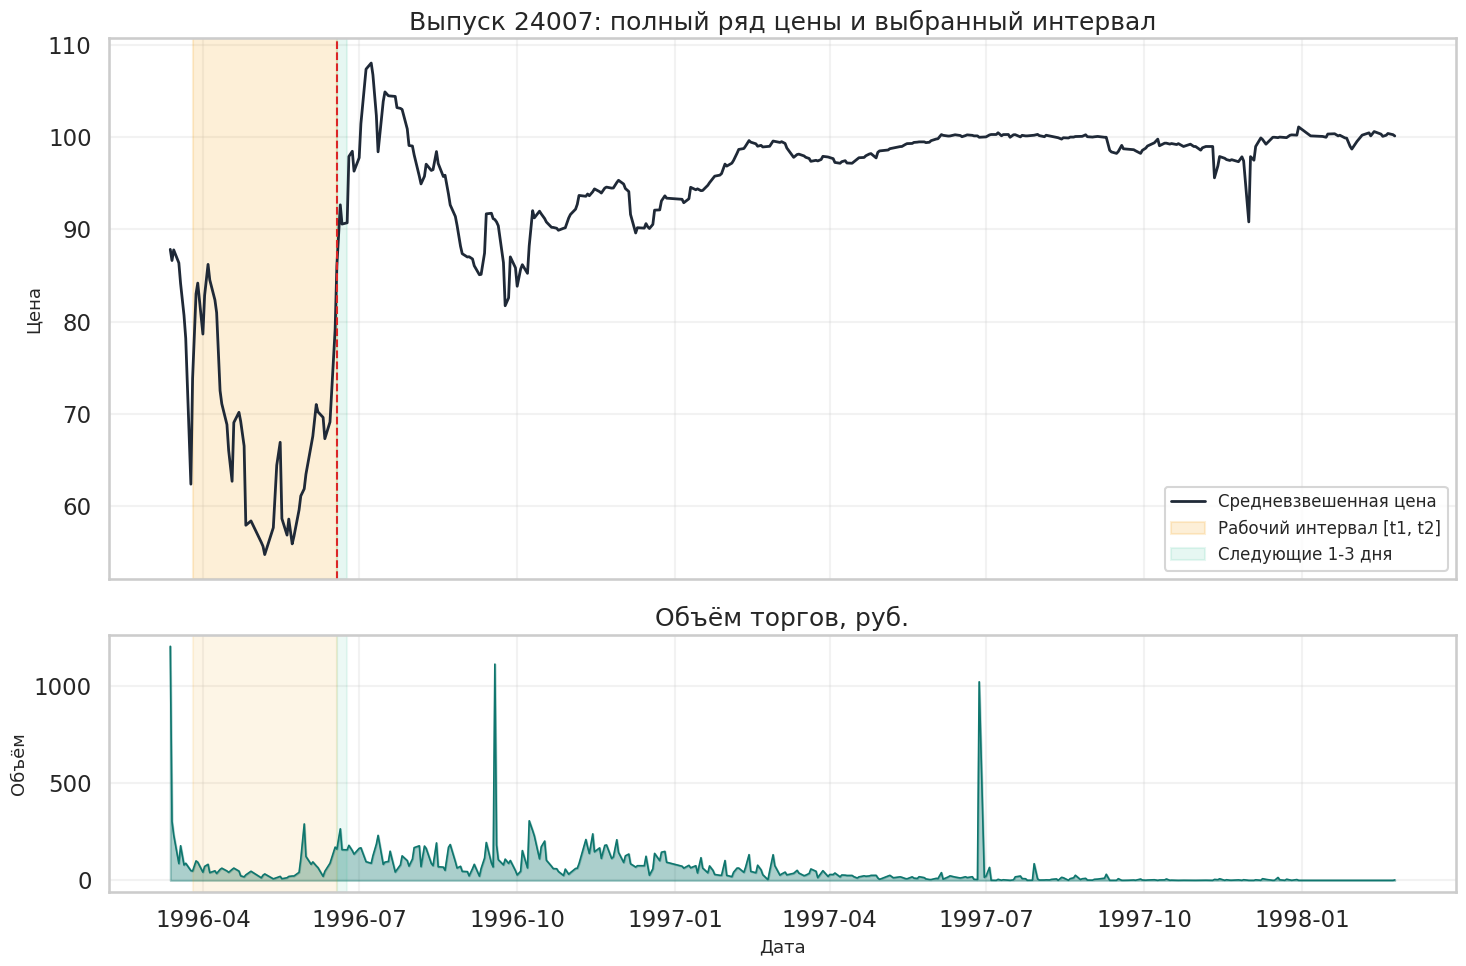

In [8]:

price_series = get_issue_series(raw_sheets[PRICE_SHEET], ISSUE_CODE, 'price')
volume_series = get_issue_series(raw_sheets[VOLUME_SHEET], ISSUE_CODE, 'volume')
series = price_series.merge(volume_series, on='date', how='left')
series['volume'] = series['volume'].fillna(0)

actual_t1, actual_t2 = resolve_interval(series, T1, T2)
future_slice = series.loc[series['date'] > actual_t2].head(max(FORECAST_HORIZONS)).copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2.1, 1]})

axes[0].plot(series['date'], series['price'], color=PRICE_COLOR, linewidth=2, label='Средневзвешенная цена')
axes[0].axvspan(actual_t1, actual_t2, color=ACCENT_COLOR, alpha=0.16, label='Рабочий интервал [t1, t2]')
if not future_slice.empty:
    axes[0].axvspan(actual_t2, future_slice['date'].iloc[-1], color=FUTURE_COLOR, alpha=0.10, label='Следующие 1-3 дня')
axes[0].axvline(actual_t2, color=ADAPT_COLOR, linestyle='--', linewidth=1.5)
axes[0].set_title(f'Выпуск {ISSUE_CODE}: полный ряд цены и выбранный интервал')
axes[0].set_ylabel('Цена')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.25)

axes[1].fill_between(series['date'], series['volume'], color=VOLUME_COLOR, alpha=0.35)
axes[1].plot(series['date'], series['volume'], color=VOLUME_COLOR, linewidth=1.2)
axes[1].axvspan(actual_t1, actual_t2, color=ACCENT_COLOR, alpha=0.10)
if not future_slice.empty:
    axes[1].axvspan(actual_t2, future_slice['date'].iloc[-1], color=FUTURE_COLOR, alpha=0.08)
axes[1].set_title('Объём торгов, руб.')
axes[1].set_ylabel('Объём')
axes[1].set_xlabel('Дата')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()



## Подбор периода сглаживания

Дальше сравнивается качество прогноза для нескольких значений `m`. Ошибка считается как `MAE` между значением среднего в момент `t` и фактической ценой через 1, 2 и 3 торговых дня.

Слева на графике видно, как меняется ошибка с ростом `m`, справа — относительное преимущество адаптивного СС над обычным `EMA`.


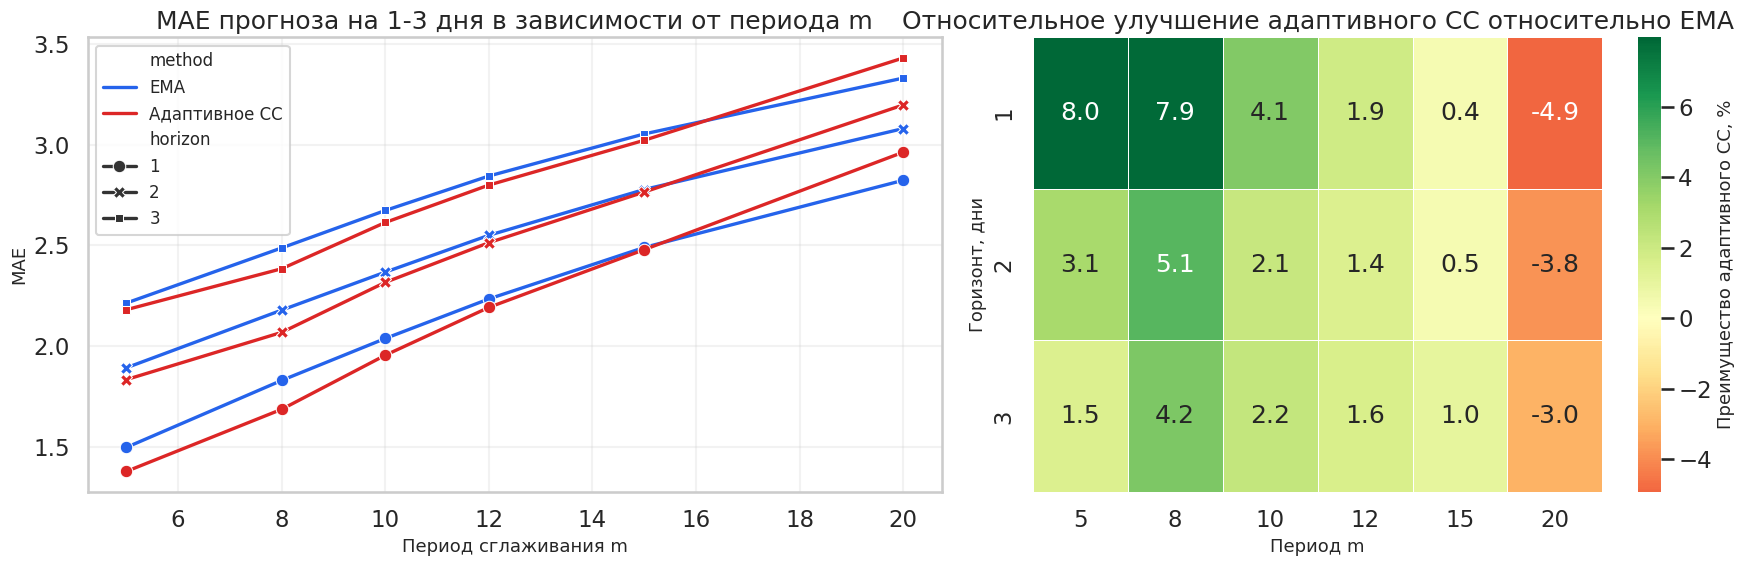

,horizon,m,adaptive_mae,ema_mae,improvement_pct,short_window,long_window
0,1,5,1.376,1.496,7.98,2,5
1,2,5,1.833,1.891,3.10,2,5
2,3,5,2.180,2.213,1.49,2,5


In [9]:

eval_table = evaluate_forecast(series[['date', 'price']], M_GRID, FORECAST_HORIZONS)

best_by_horizon = eval_table.loc[eval_table.groupby('horizon')['adaptive_mae'].idxmin()].copy()
best_by_horizon['adaptive_mae'] = best_by_horizon['adaptive_mae'].round(3)
best_by_horizon['ema_mae'] = best_by_horizon['ema_mae'].round(3)
best_by_horizon['improvement_pct'] = best_by_horizon['improvement_pct'].round(2)

plot_df = eval_table.melt(
    id_vars=['m', 'horizon'],
    value_vars=['ema_mae', 'adaptive_mae'],
    var_name='method',
    value_name='mae',
)
plot_df['method'] = plot_df['method'].map({'ema_mae': 'EMA', 'adaptive_mae': 'Адаптивное СС'})

heatmap_df = eval_table.pivot(index='horizon', columns='m', values='improvement_pct')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 1]})
sns.lineplot(
    data=plot_df,
    x='m',
    y='mae',
    hue='method',
    style='horizon',
    markers=True,
    dashes=False,
    linewidth=2.4,
    palette=[EMA_COLOR, ADAPT_COLOR],
    ax=axes[0],
)
axes[0].set_title('MAE прогноза на 1-3 дня в зависимости от периода m')
axes[0].set_xlabel('Период сглаживания m')
axes[0].set_ylabel('MAE')
axes[0].grid(alpha=0.25)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Преимущество адаптивного СС, %'},
    ax=axes[1],
)
axes[1].set_title('Относительное улучшение адаптивного СС относительно EMA')
axes[1].set_xlabel('Период m')
axes[1].set_ylabel('Горизонт, дни')

plt.tight_layout()
plt.show()

best_by_horizon[['horizon', 'm', 'adaptive_mae', 'ema_mae', 'improvement_pct', 'short_window', 'long_window']]



## Графическое сравнение `EMA` и адаптивного СС

Здесь показан уже не весь ряд, а рабочий участок, на котором лучше всего видно различие двух сглаживаний. На нижнем графике дополнительно вынесены адаптивный коэффициент `alpha_t` и отношение краткосрочной и долгосрочной волатильности.


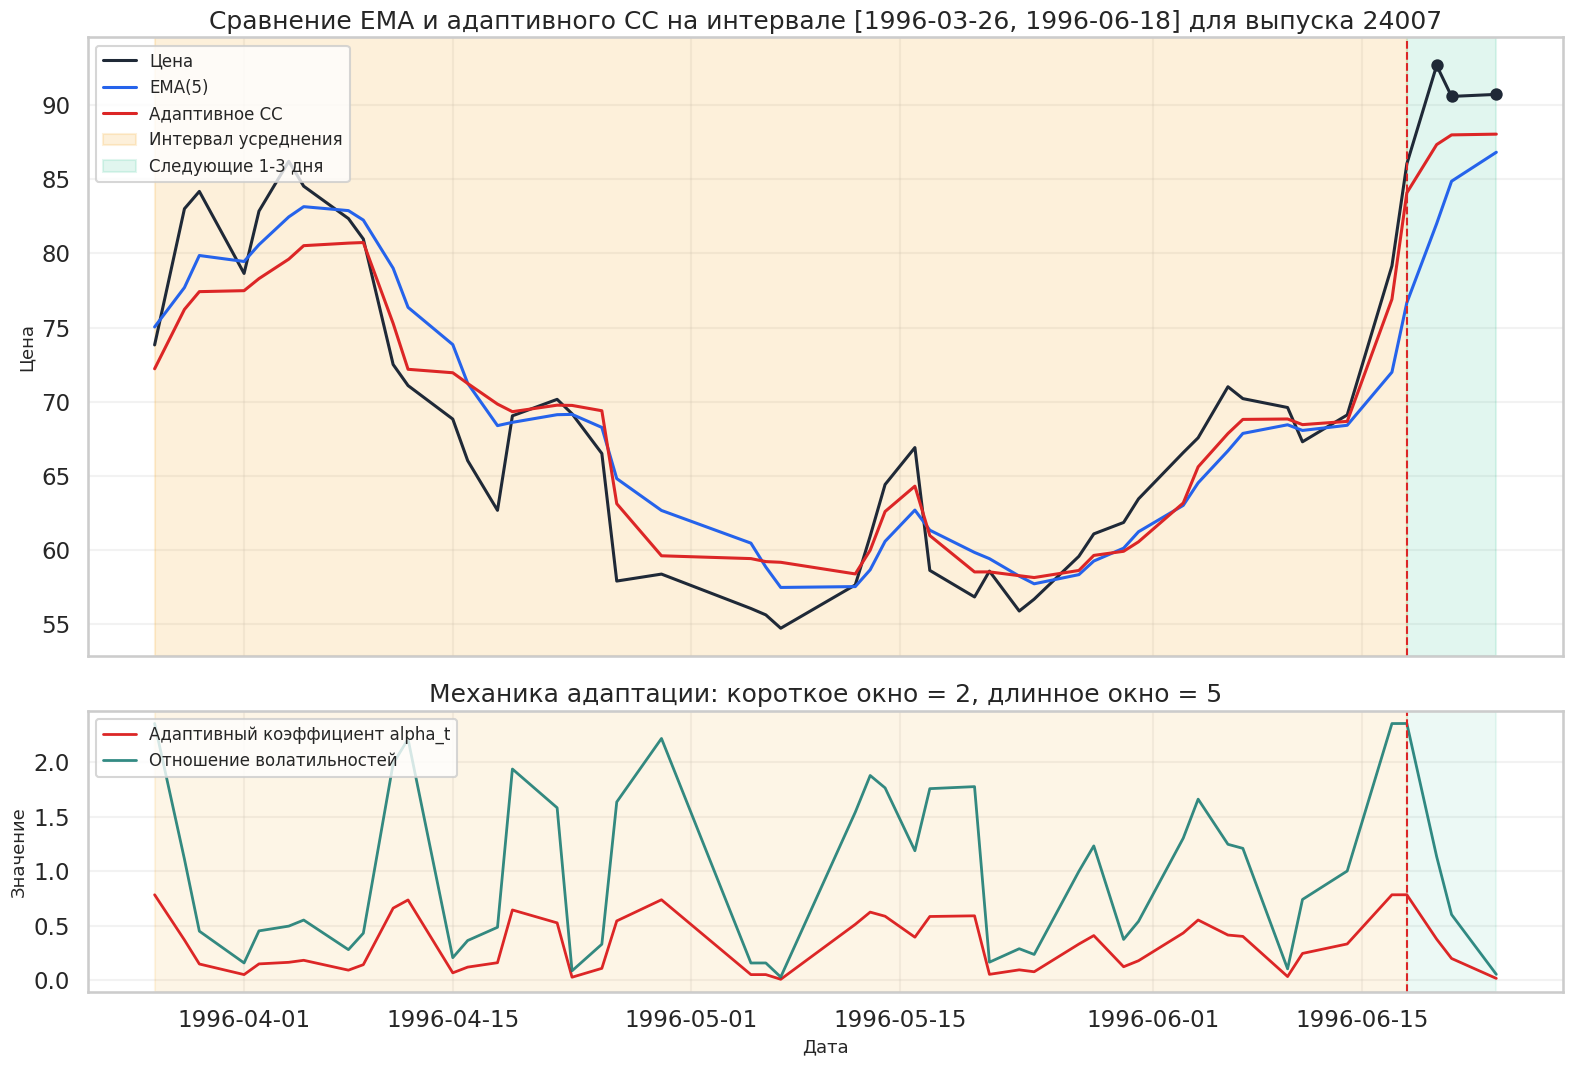

In [10]:

values = series['price'].to_numpy()
series = series.copy()
series['ema'] = ema(values, EMA_PERIOD)
series['adaptive'], series['alpha'], series['vol_ratio'], short_window, long_window = adaptive_ema(values, EMA_PERIOD)

interval_end_idx = series.index[series['date'] == actual_t2][0]
plot_end_idx = min(len(series) - 1, interval_end_idx + max(FORECAST_HORIZONS))
plot_mask = (series.index >= 0) & (series.index <= plot_end_idx)
plot_frame = series.loc[plot_mask].copy()
plot_frame = plot_frame[plot_frame['date'] >= actual_t1]

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})

axes[0].plot(plot_frame['date'], plot_frame['price'], color=PRICE_COLOR, linewidth=2.2, label='Цена')
axes[0].plot(plot_frame['date'], plot_frame['ema'], color=EMA_COLOR, linewidth=2.2, label=f'EMA({EMA_PERIOD})')
axes[0].plot(plot_frame['date'], plot_frame['adaptive'], color=ADAPT_COLOR, linewidth=2.2, label='Адаптивное СС')
axes[0].axvspan(actual_t1, actual_t2, color=ACCENT_COLOR, alpha=0.15, label='Интервал усреднения')
if not future_slice.empty:
    axes[0].axvspan(actual_t2, future_slice['date'].iloc[-1], color=FUTURE_COLOR, alpha=0.12, label='Следующие 1-3 дня')
    axes[0].scatter(future_slice['date'], future_slice['price'], color=PRICE_COLOR, s=55, zorder=5)
axes[0].axvline(actual_t2, color=ADAPT_COLOR, linestyle='--', linewidth=1.5)
axes[0].set_title(
    f'Сравнение EMA и адаптивного СС на интервале [{actual_t1.date()}, {actual_t2.date()}] для выпуска {ISSUE_CODE}'
)
axes[0].set_ylabel('Цена')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.25)

axes[1].plot(plot_frame['date'], plot_frame['alpha'], color=ADAPT_COLOR, linewidth=2, label='Адаптивный коэффициент alpha_t')
axes[1].plot(plot_frame['date'], plot_frame['vol_ratio'], color=VOLUME_COLOR, linewidth=2, alpha=0.85, label='Отношение волатильностей')
axes[1].axvspan(actual_t1, actual_t2, color=ACCENT_COLOR, alpha=0.10)
if not future_slice.empty:
    axes[1].axvspan(actual_t2, future_slice['date'].iloc[-1], color=FUTURE_COLOR, alpha=0.08)
axes[1].axvline(actual_t2, color=ADAPT_COLOR, linestyle='--', linewidth=1.5)
axes[1].set_title(
    f'Механика адаптации: короткое окно = {short_window}, длинное окно = {long_window}'
)
axes[1].set_ylabel('Значение')
axes[1].set_xlabel('Дата')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()



## Сравнение с фактической ценой после `t2`

В таблице ниже значение средних фиксируется в точке `t2`, после чего сравнивается с реальной ценой через 1, 2 и 3 торговых дня. Это и есть локальная проверка того, насколько полезно сглаживание для очень короткого прогноза.


In [11]:

base_ema = float(series.loc[series['date'] == actual_t2, 'ema'].iloc[0])
base_adaptive = float(series.loc[series['date'] == actual_t2, 'adaptive'].iloc[0])
comparison_rows = []

for horizon in FORECAST_HORIZONS:
    future_part = series.loc[series['date'] > actual_t2].head(horizon)
    if len(future_part) < horizon:
        continue
    row = future_part.iloc[-1]
    ema_error = abs(base_ema - row['price'])
    adaptive_error = abs(base_adaptive - row['price'])
    comparison_rows.append({
        'horizon_days': horizon,
        'future_date': row['date'].date(),
        'actual_price': row['price'],
        'ema_at_t2': base_ema,
        'adaptive_at_t2': base_adaptive,
        'ema_abs_error': ema_error,
        'adaptive_abs_error': adaptive_error,
        'winner': 'Адаптивное СС' if adaptive_error < ema_error else 'EMA',
        'improvement_pct': 100 * (ema_error - adaptive_error) / ema_error if ema_error else np.nan,
    })

future_comparison = pd.DataFrame(comparison_rows)
future_comparison[['actual_price', 'ema_at_t2', 'adaptive_at_t2', 'ema_abs_error', 'adaptive_abs_error', 'improvement_pct']] = (
    future_comparison[['actual_price', 'ema_at_t2', 'adaptive_at_t2', 'ema_abs_error', 'adaptive_abs_error', 'improvement_pct']].round(3)
)

future_comparison


,horizon_days,future_date,actual_price,ema_at_t2,adaptive_at_t2,ema_abs_error,adaptive_abs_error,winner,improvement_pct
0,1,1996-06-20,92.670,76.677,84.085,15.993,8.585,Адаптивное СС,46.321
1,2,1996-06-21,90.583,76.677,84.085,13.907,6.499,Адаптивное СС,53.270
2,3,1996-06-24,90.720,76.677,84.085,14.043,6.635,Адаптивное СС,52.752



## Краткий отчет и выводы

Текст ниже относится к текущим параметрам ноутбука: лист **`Цены (средневзвешенные)`**, выпуск **`24007`**, период сглаживания на основном графике **`m = 5`**, интервал **`[1996-03-26, 1996-06-18]`**.

### 1. Что находится в Excel-файле

Файл содержит несколько типов данных по одним и тем же выпускам облигаций:
- `Инфо` — справочник по выпускам с датами аукциона и погашения;
- `Цены (средневзвешенные)`, `Цены (last)`, `Цены (мин)`, `Цены (макс)` — разные представления цены;
- `Объёмы (руб)` и `Объёмы (шт)` — торговая активность;
- `Купоны`, `Размещения`, `Объёмы в обращении` — дополнительные характеристики выпуска.

Для задачи построения адаптивного среднего выбран именно лист **`Цены (средневзвешенные)`**, потому что он лучше отражает рыночную цену дня, чем `last`, а `min/max` являются экстремумами и сильнее шумят.

### 2. Какой ряд выбран

Для анализа выбран выпуск **`24007`**. По справочному листу дата аукциона этого выпуска — **1996-03-13**, дата погашения — **1998-03-11**. В ценовом ряду используется **379** торговых наблюдений, поэтому ряд достаточно длинный для сравнения сглаживаний и подбора параметра `m`.

### 3. Подбор периода сглаживания `m`

Для горизонтов прогноза 1, 2 и 3 торговых дня лучшим в протестированной сетке `m = [5, 8, 10, 12, 15, 20]` оказался период **`m = 5`**.

Для адаптивного СС при `m = 5` получены такие ошибки:
- горизонт 1 день: `MAE = 1.376`, улучшение относительно `EMA` — `7.98%`;
- горизонт 2 дня: `MAE = 1.833`, улучшение относительно `EMA` — `3.10%`;
- горизонт 3 дня: `MAE = 2.180`, улучшение относительно `EMA` — `1.49%`.

Значит, на этом выпуске для короткого прогноза лучше работают небольшие периоды сглаживания. При росте `m` среднее становится слишком инерционным, а при `m = 20` адаптивное СС уже уступает обычному `EMA`.

### 4. Что видно на выбранном интервале

На интервале **`[1996-03-26, 1996-06-18]`** ряд проходит через падение, разворот и резкий рост. Вблизи разворота адаптивное среднее заметно быстрее увеличивает коэффициент `alpha_t`, поэтому раньше подтягивается к цене, чем стандартный `EMA(5)`.

Именно на таких участках и проявляется смысл адаптивного сглаживания: при спокойном рынке оно близко к обычному `EMA`, а при всплеске локальной волатильности начинает реагировать быстрее.

### 5. Проверка на следующих 1-3 днях после `t2`

Если взять значения средних в точке **`1996-06-18`** и сравнить их с фактической ценой дальше, то адаптивное СС оказывается ближе к реальному ряду на каждом из трех горизонтов:
- через 1 день ошибка меньше на `46.3%`;
- через 2 дня ошибка меньше на `53.3%`;
- через 3 дня ошибка меньше на `52.8%`.

Среднее сокращение ошибки на этом участке составляет примерно **`50.8%`** относительно стандартного `EMA`.

### 6. Итоговый вывод

Адаптивное скользящее среднее на этом датасете действительно полезно для короткого прогноза, когда рынок быстро меняет режим. Для выбранного выпуска и для горизонта 1-3 дня разумно использовать **малые значения `m`**, прежде всего **`m = 5`**, а как более гладкую альтернативу можно рассматривать **`m = 8`**.
